In [1]:
!pip install segmentation-models-pytorch --quiet

import segmentation_models_pytorch as smp
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights="imagenet",     
    in_channels=3,                  
    classes=1,                     
)

model.to(device)
print("Pre-trained UNet with ResNet34 backbone loaded.")

c:\Users\ilaki\anaconda3\envs\sih_segmentation\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Pre-trained UNet with ResNet34 backbone loaded.


In [2]:
import os
import numpy as np
from PIL import Image
from pycocotools.coco import COCO

ann_dir = r"C:\Users\ilaki\Desktop\VISON_AI\coco2017\annotations"
img_dir = r"C:\Users\ilaki\Desktop\VISON_AI\coco2017\val2017"
out_mask_dir = r"C:\Users\ilaki\Desktop\VISON_AI\coco2017\BinaryMasks"
os.makedirs(out_mask_dir, exist_ok=True)

json_files = [f for f in os.listdir(ann_dir) if f.endswith(".json")]

for json_file in json_files:
    ann_path = os.path.join(ann_dir, json_file)
    coco = COCO(ann_path)

    img_ids = coco.getImgIds()
    for img_id in img_ids:
        img_info = coco.loadImgs(img_id)[0]
        anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))

        mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)
        for ann in anns:
            if 'segmentation' in ann and ann['segmentation']:
                mask = np.maximum(mask, coco.annToMask(ann) * 255)

        mask_img = Image.fromarray(mask)
        mask_name = img_info['file_name'].replace(".jpg", ".png")
        mask_img.save(os.path.join(out_mask_dir, mask_name))

print("Mask generation completed!")


loading annotations into memory...
Done (t=3.55s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=14.22s)
creating index...
index created!
loading annotations into memory...
Done (t=2.66s)
creating index...
index created!
loading annotations into memory...
Done (t=5.75s)
creating index...
index created!
loading annotations into memory...
Done (t=0.23s)
creating index...
index created!
Mask generation completed!


In [1]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import os
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

images_dir = r"C:\Users\ilaki\Desktop\VISON_AI\coco2017\val2017"
masks_dir = r"C:\Users\ilaki\Desktop\VISON_AI\coco2017\BinaryMasks"

class SegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform_img=None, transform_mask=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_files = sorted([f for f in os.listdir(images_dir) if f.endswith(".jpg")])
        self.mask_files = set([f for f in os.listdir(masks_dir) if f.endswith(".png")])
        self.valid_pairs = [(img, img.replace(".jpg", ".png")) for img in self.image_files
                            if img.replace(".jpg", ".png") in self.mask_files]
        self.transform_img = transform_img
        self.transform_mask = transform_mask
        print(f"Dataset initialized with {len(self.valid_pairs)} image-mask pairs.")

    def __len__(self):
        return len(self.valid_pairs)

    def __getitem__(self, idx):
        img_name, mask_name = self.valid_pairs[idx]
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, mask_name)
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        if self.transform_img:
            image = self.transform_img(image)
        if self.transform_mask:
            mask = self.transform_mask(mask)
            mask = (mask > 0).float()
        return image, mask

transform_img = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])
transform_mask = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

dataset = SegmentationDataset(images_dir, masks_dir, transform_img=transform_img, transform_mask=transform_mask)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0, pin_memory=True)

print("Loading a single epoch to check speed...")
for images, masks in tqdm(train_loader, desc="Training batches"):
    pass

print("Loader working ✅")


Dataset initialized with 5000 image-mask pairs.
Loading a single epoch to check speed...


Training batches: 100%|██████████| 1000/1000 [00:54<00:00, 18.36it/s]

Loader working ✅


In [2]:
import torch
import torch.nn as nn
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)

model.to(device)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\ilaki/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth
100%|██████████| 161M/161M [00:52<00:00, 3.21MB/s] 


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 50
scaler = torch.cuda.amp.GradScaler()

def freeze_backbone(model, freeze=True):
    for param in model.backbone.parameters():
        param.requires_grad = not freeze

freeze_backbone(model, freeze=True)

def train_and_validate(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, checkpoint_interval=5):
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(images)["out"]
                loss = criterion(outputs, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * images.size(0)
        avg_train_loss = train_loss / len(train_loader.dataset)
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(images)["out"]
                    loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)
        avg_val_loss = val_loss / len(val_loader.dataset)
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        if (epoch + 1) % checkpoint_interval == 0:
            torch.save(model.state_dict(), f"deeplabv3_epoch{epoch+1}.pth")
        if epoch + 1 == 5:
            freeze_backbone(model, freeze=False)
    return model

trained_model = train_and_validate(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)
torch.save(trained_model.state_dict(), "deeplabv3_binary_50epochs_final.pth")


C:\Users\ilaki\AppData\Local\Temp\ipykernel_28444\446030903.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\ilaki\AppData\Local\Temp\ipykernel_28444\446030903.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\ilaki\AppData\Local\Temp\ipykernel_28444\446030903.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/50] - Train Loss: 0.1634, Val Loss: 0.1294
Epoch [2/50] - Train Loss: 0.1435, Val Loss: 0.1203
Epoch [3/50] - Train Loss: 0.1391, Val Loss: 0.1133
Epoch [4/50] - Train Loss: 0.1332, Val Loss: 0.1300
Epoch [5/50] - Train Loss: 0.1320, Val Loss: 0.1156
Epoch [6/50] - Train Loss: 0.1379, Val Loss: 0.1021
Epoch [7/50] - Train Loss: 0.1136, Val Loss: 0.0993
Epoch [8/50] - Train Loss: 0.0987, Val Loss: 0.1040
Epoch [9/50] - Train Loss: 0.0960, Val Loss: 0.1217
Epoch [10/50] - Train Loss: 0.0756, Val Loss: 0.1083
Epoch [11/50] - Train Loss: 0.0732, Val Loss: 0.1023
Epoch [12/50] - Train Loss: 0.0754, Val Loss: 0.1252
Epoch [13/50] - Train Loss: 0.0683, Val Loss: 0.0904
Epoch [14/50] - Train Loss: 0.0509, Val Loss: 0.0936
Epoch [15/50] - Train Loss: 0.0725, Val Loss: 0.1090
Epoch [16/50] - Train Loss: 0.0618, Val Loss: 0.0975
Epoch [17/50] - Train Loss: 0.0488, Val Loss: 0.0928
Epoch [18/50] - Train Loss: 0.0438, Val Loss: 0.1044
Epoch [19/50] - Train Loss: 0.0514, Val Loss: 0.1064
Ep

KeyboardInterrupt: 

C:\Users\ilaki\AppData\Local\Temp\ipykernel_28444\2719852956.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_location=devic

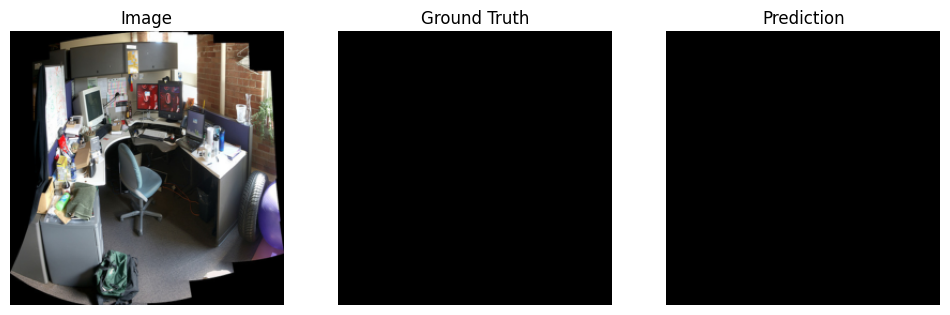

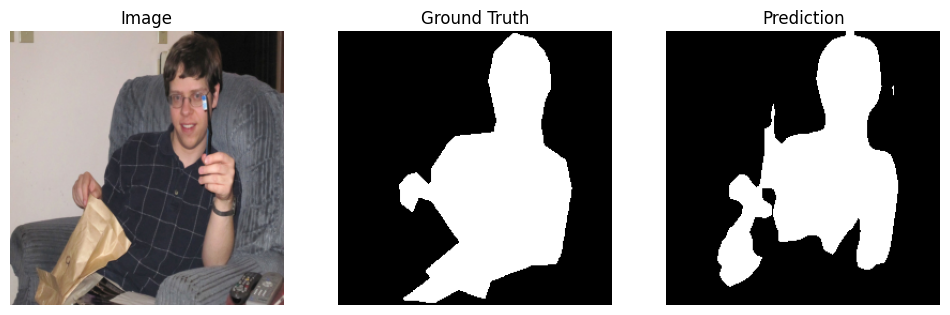

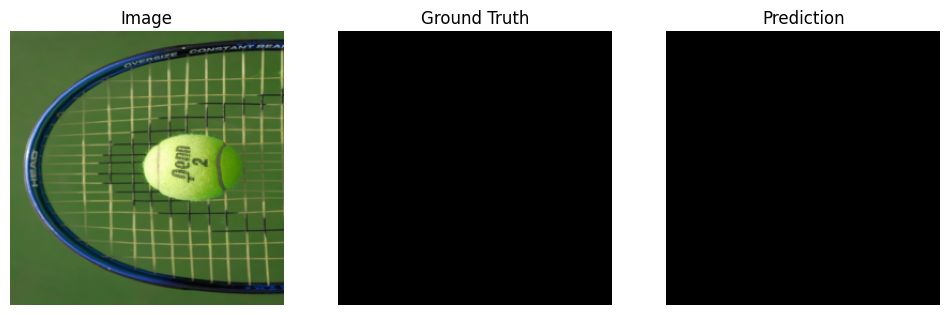

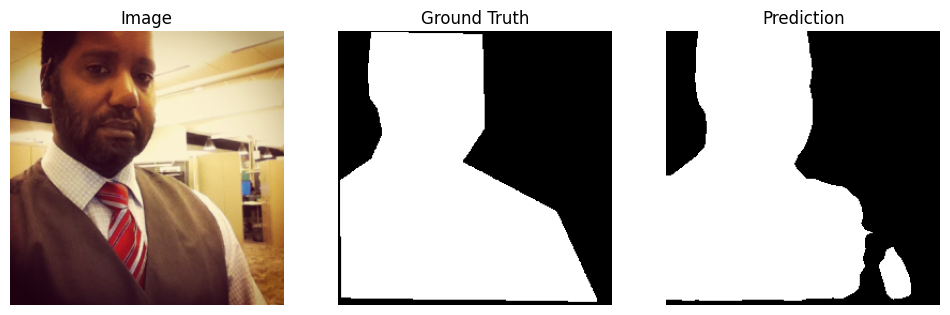

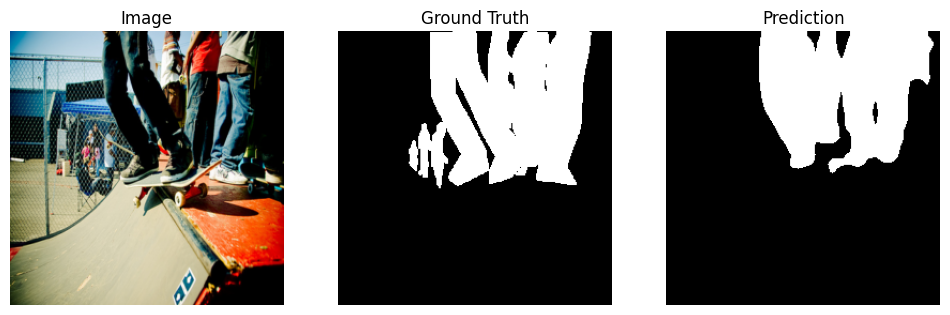

In [7]:
import torch
import matplotlib.pyplot as plt
import torchvision.models.segmentation as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.deeplabv3_resnet50(pretrained=False, num_classes=1, aux_loss=False)
model.to(device)

checkpoint_path = "deeplabv3_epoch20.pth"
state_dict = torch.load(checkpoint_path, map_location=device)

state_dict = {k: v for k, v in state_dict.items() if "aux_classifier" not in k}
model.load_state_dict(state_dict, strict=False)

def evaluate_and_visualize(model, val_loader, device, num_samples=3):
    model.eval()
    samples = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)["out"]
            preds = torch.sigmoid(outputs) > 0.5
            for i in range(images.size(0)):
                if samples >= num_samples:
                    return
                img = images[i].cpu().permute(1, 2, 0).numpy()
                gt = masks[i].cpu().squeeze().numpy()
                pred = preds[i].cpu().squeeze().numpy()
                fig, axs = plt.subplots(1, 3, figsize=(12, 4))
                axs[0].imshow(img)
                axs[0].set_title("Image")
                axs[1].imshow(gt, cmap="gray")
                axs[1].set_title("Ground Truth")
                axs[2].imshow(pred, cmap="gray")
                axs[2].set_title("Prediction")
                for ax in axs:
                    ax.axis("off")
                plt.show()
                samples += 1

evaluate_and_visualize(model, val_loader, device, num_samples=5)


In [17]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from skimage.draw import polygon
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Hyperparameters
num_epochs = 5
batch_size = 6
learning_rate = 1e-4
weight_decay = 1e-5
image_size = 256
num_classes = 2
checkpoint_path = "deeplabv3_epoch20.pth"  # your previous checkpoint

# Dataset class
class CocoMaskedDataset(Dataset):
    def __init__(self, images_path, annotations_path, transform=None):
        self.images_path = images_path
        self.transform = transform
        import json
        with open(annotations_path, "r") as f:
            coco = json.load(f)
        self.images = {img["id"]: img["file_name"] for img in coco["images"]}
        self.annotations = {}
        for ann in coco["annotations"]:
            img_id = ann["image_id"]
            if img_id not in self.annotations:
                self.annotations[img_id] = []
            self.annotations[img_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_id = list(self.images.keys())[idx]
        img_path = os.path.join(self.images_path, self.images[img_id])
        img = np.array(Image.open(img_path).convert("RGB"))
        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        anns = self.annotations.get(img_id, [])
        for ann in anns:
            for seg in ann["segmentation"]:
                if isinstance(seg, list) and len(seg) % 2 == 0:
                    poly = np.array(seg).reshape(-1, 2)
                    rr, cc = polygon(poly[:, 1], poly[:, 0], shape=img.shape[:2])
                    mask[rr, cc] = 1
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]
        return img, mask.long()

# Transforms
train_transform = A.Compose([
    A.Resize(image_size, image_size),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(p=0.3),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])
val_transform = A.Compose([
    A.Resize(image_size, image_size),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# Paths
images_path = r"C:\Users\ilaki\Desktop\VISON_AI\coco2017\val2017"
annotations_path = r"C:\Users\ilaki\Desktop\VISON_AI\coco2017\annotations\instances_val2017.json"

dataset = CocoMaskedDataset(images_path, annotations_path, transform=train_transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# Model
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights, aux_loss=True)
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scaler = torch.cuda.amp.GradScaler()

# Freeze backbone initially
def freeze_backbone(model, freeze=True):
    for param in model.backbone.parameters():
        param.requires_grad = not freeze

freeze_backbone(model, freeze=True)

# Load checkpoint (ignore classifier weights)
checkpoint = torch.load(checkpoint_path, map_location=device)
model_dict = model.state_dict()
filtered_dict = {k: v for k, v in checkpoint.items() if "classifier.4" not in k}
model_dict.update(filtered_dict)
model.load_state_dict(model_dict)
print("Checkpoint loaded, classifier head reinitialized for new num_classes.")

# Training function
def train_resume(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, start_epoch=21, checkpoint_interval=5):
    best_val_loss = float("inf")
    backbone_unfrozen = False
    for epoch in range(start_epoch, start_epoch + num_epochs):
        model.train()
        train_loss = 0.0
        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{start_epoch+num_epochs-1} [Training]", leave=False):
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(images)["out"]
                loss = criterion(outputs, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * images.size(0)
        avg_train_loss = train_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(images)["out"]
                    loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)
        avg_val_loss = val_loss / len(val_loader.dataset)

        print(f"Epoch [{epoch}/{start_epoch+num_epochs-1}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f"deeplabv3_resumed_best.pth")
            print("Best model updated!")

        # Unfreeze backbone after first epoch
        if not backbone_unfrozen:
            freeze_backbone(model, freeze=False)
            backbone_unfrozen = True
            print("Backbone unfrozen, fine-tuning full model!")

        # Save checkpoint
        if (epoch - start_epoch + 1) % checkpoint_interval == 0:
            torch.save(model.state_dict(), f"deeplabv3_resumed_epoch{epoch}.pth")

    return model

# Run resumed training
trained_model = train_resume(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)
torch.save(trained_model.state_dict(), "deeplabv3_resumed_final.pth")
print("Resumed training complete!")


Using device: cuda


C:\Users\ilaki\AppData\Local\Temp\ipykernel_19788\1525284425.py:99: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\ilaki\AppData\Local\Temp\ipykernel_19788\1525284425.py:109: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `

Checkpoint loaded, classifier head reinitialized for new num_classes.


Epoch 21/25 [Training]:   0%|          | 0/667 [00:00<?, ?it/s]C:\Users\ilaki\AppData\Local\Temp\ipykernel_19788\1525284425.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\ilaki\AppData\Local\Temp\ipykernel_19788\1525284425.py:140: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [21/25] - Train Loss: 0.4129, Val Loss: 0.3548
Best model updated!
Backbone unfrozen, fine-tuning full model!


Epoch [22/25] - Train Loss: 0.3452, Val Loss: 0.3004
Best model updated!


Epoch [23/25] - Train Loss: 0.2934, Val Loss: 0.2950
Best model updated!


Epoch [24/25] - Train Loss: 0.2548, Val Loss: 0.3051


Epoch [25/25] - Train Loss: 0.2216, Val Loss: 0.3032
Resumed training complete!


Mean IoU: 0.7205, Mean Dice: 0.8271, Pixel Accuracy: 0.8683


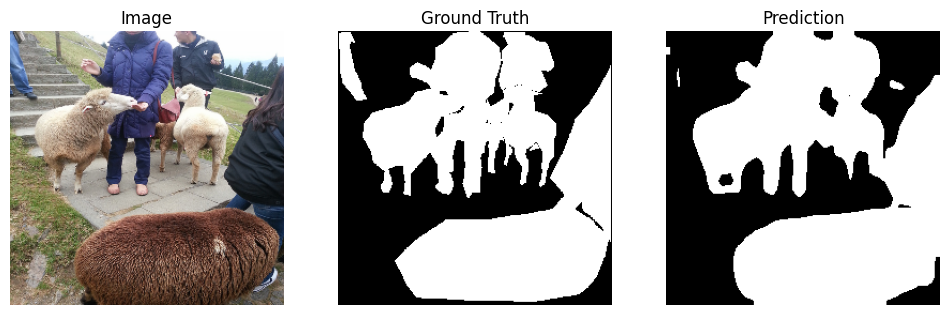

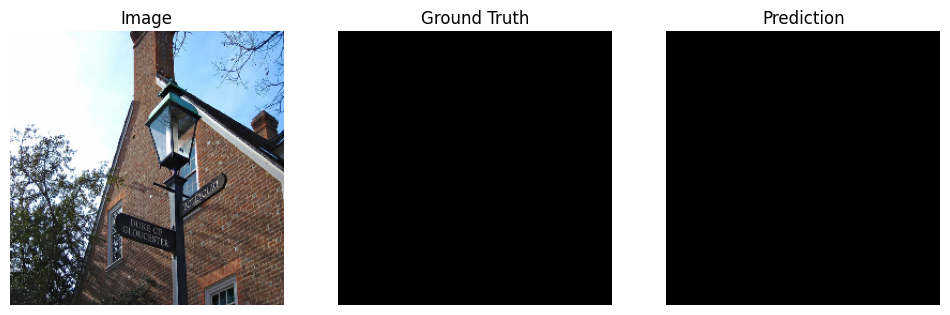

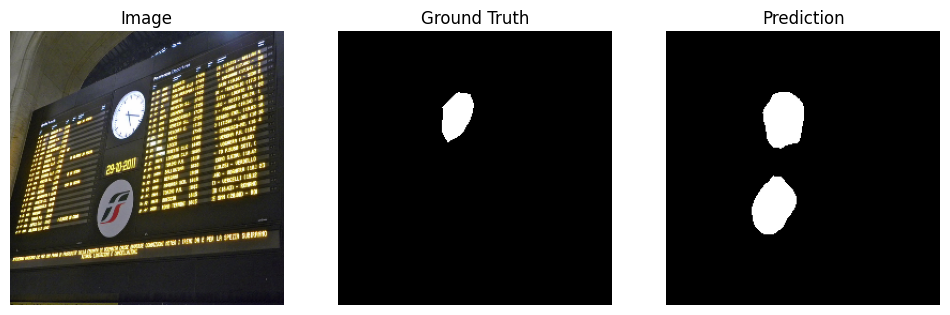

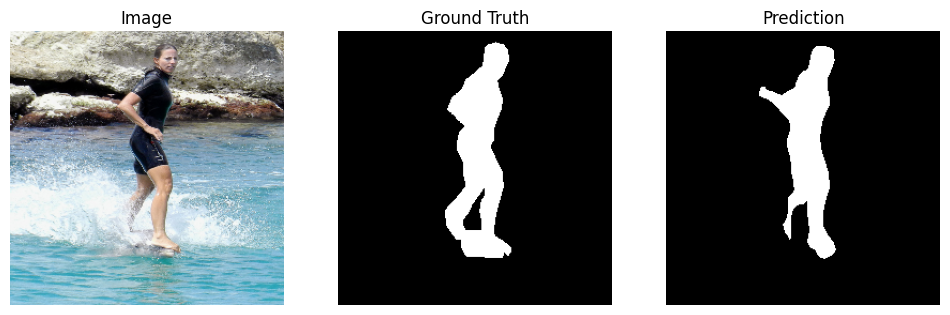

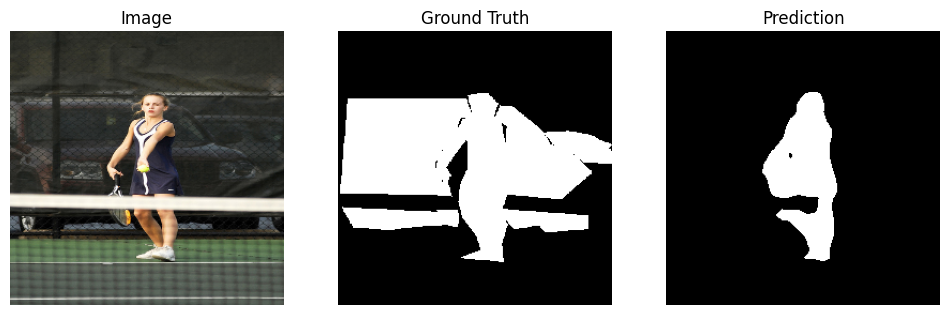

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def iou_score(preds, masks, num_classes=2):
    preds = torch.argmax(preds, dim=1)
    ious = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (masks == cls)
        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()
        ious.append((intersection / union).item() if union != 0 else float('nan'))
    return np.nanmean(ious)

def dice_score(preds, masks, num_classes=2):
    preds = torch.argmax(preds, dim=1)
    dices = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (masks == cls)
        intersection = (pred_inds & target_inds).sum().float() * 2
        denominator = pred_inds.sum().float() + target_inds.sum().float()
        dices.append((intersection / denominator).item() if denominator != 0 else float('nan'))
    return np.nanmean(dices)

def pixel_accuracy(preds, masks):
    preds = torch.argmax(preds, dim=1)
    correct = (preds == masks).sum().float()
    total = torch.numel(masks)
    return (correct / total).item()

def evaluate_model(model, dataloader, device):
    model.eval()
    metrics = {"IoU": [], "Dice": [], "PixelAcc": []}
    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)["out"]
            metrics["IoU"].append(iou_score(outputs, masks))
            metrics["Dice"].append(dice_score(outputs, masks))
            metrics["PixelAcc"].append(pixel_accuracy(outputs, masks))
    print(f"Mean IoU: {np.mean(metrics['IoU']):.4f}, Mean Dice: {np.mean(metrics['Dice']):.4f}, Pixel Accuracy: {np.mean(metrics['PixelAcc']):.4f}")

# Prediction & Visualization
def visualize_predictions(model, dataloader, device, num_samples=5):
    model.eval()
    samples = 0
    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs = imgs.to(device)
            outputs = model(imgs)["out"]
            preds = torch.argmax(outputs, dim=1).cpu()
            
            for i in range(imgs.size(0)):
                img = imgs[i].cpu().permute(1, 2, 0).numpy()
                # un-normalize
                img = np.clip(img * (0.229, 0.224, 0.225) + (0.485, 0.456, 0.406), 0, 1)
                mask_gt = masks[i].cpu().numpy()
                mask_pred = preds[i].numpy()
                
                fig, axs = plt.subplots(1, 3, figsize=(12, 4))
                axs[0].imshow(img); axs[0].set_title("Image"); axs[0].axis("off")
                axs[1].imshow(mask_gt, cmap="gray"); axs[1].set_title("Ground Truth"); axs[1].axis("off")
                axs[2].imshow(mask_pred, cmap="gray"); axs[2].set_title("Prediction"); axs[2].axis("off")
                plt.show()
                
                samples += 1
                if samples >= num_samples:
                    return

# Run
evaluate_model(trained_model, val_loader, device)
visualize_predictions(trained_model, val_loader, device, num_samples=5)
